# Run 5 — Tests de significativité statistique (Wilcoxon)

**Objectif** : Vérifier que les différences de performances entre méthodes sont statistiquement significatives.

**Test utilisé** : Wilcoxon signed-rank test (apparié, image par image) sur les DSC du test set ISBI 2016 (379 images).

**Comparaisons** :
1. K-means LAB vs CNN patch (P=32)
2. CNN patch (P=32) vs U-Net baseline
3. U-Net baseline vs U-Net final
4. K-means LAB vs U-Net final (gain global)

In [6]:
import os, json
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt

## 1. Charger les DSC par image (U-Net)

In [7]:
with open('results_test_evaluation.json') as f:
    test_results = json.load(f)

# U-Net FINAL
final_per_image = test_results['FINAL']['per_image']
final_images = [r['image'] for r in final_per_image]
final_dsc    = np.array([r['dice'] for r in final_per_image])

# U-Net baseline
baseline_per_image = test_results['baseline_f64-d4-skip-bce+dice']['per_image']
baseline_images = [r['image'] for r in baseline_per_image]
baseline_dsc    = np.array([r['dice'] for r in baseline_per_image])

# Vérifier l'alignement
assert final_images == baseline_images, "Images non alignées entre FINAL et baseline"
print(f"U-Net chargé: {len(final_dsc)} images")
print(f"  FINAL   — DSC: {final_dsc.mean():.4f} ± {final_dsc.std():.4f}")
print(f"  Baseline— DSC: {baseline_dsc.mean():.4f} ± {baseline_dsc.std():.4f}")

U-Net chargé: 379 images
  FINAL   — DSC: 0.8819 ± 0.1300
  Baseline— DSC: 0.8634 ± 0.1432


## 2. Calculer les DSC par image (K-means LAB)

Les DSC per-image du K-means n'ont pas été sauvegardés en JSON. On les recalcule sur les 379 images de test.

In [8]:
from skimage import color
from sklearn.cluster import KMeans
from scipy import ndimage
from PIL import Image
import glob as _glob

# Paths (compatible Onyxia / Kaggle)
_kaggle = _glob.glob('/kaggle/input/*/dataset_ISIC')
if _kaggle:
    _base = _kaggle[0]
else:
    _base = 'dataset_ISIC'

from pathlib import Path
BASE = Path(_base)
TEST_IMG_DIR  = BASE / 'ISBI2016_ISIC_Part1_Test_Data'
TEST_MASK_DIR = BASE / 'ISBI2016_ISIC_Part1_Test_GroundTruth'

test_img_paths  = sorted(TEST_IMG_DIR.glob('*.jpg'))
test_mask_paths = sorted(TEST_MASK_DIR.glob('*.png'))
assert len(test_img_paths) == 379, f"Attendu 379 images, trouvé {len(test_img_paths)}"
print(f"Test set: {len(test_img_paths)} images")
print(f"Path: {TEST_IMG_DIR}")

Test set: 379 images
Path: dataset_ISIC/ISBI2016_ISIC_Part1_Test_Data


In [9]:
def load_img(path):
    return np.array(Image.open(path).convert('RGB')) / 255.0

def load_mask(path):
    m = np.array(Image.open(path).convert('L'))
    return (m > 127).astype(np.float32)

def keep_largest_component(mask):
    labeled, n = ndimage.label(mask)
    if n <= 1:
        return mask
    sizes = ndimage.sum(mask, labeled, range(1, n + 1))
    largest = np.argmax(sizes) + 1
    return (labeled == largest).astype(np.float32)

def dice_score(y_true, y_pred):
    inter = np.sum(y_true * y_pred)
    total = np.sum(y_true) + np.sum(y_pred)
    if total == 0:
        return 1.0
    return 2.0 * inter / total

def kmeans_lab_segment(img_rgb, k=2):
    """Segmentation K-means dans l'espace LAB, heuristique sombre."""
    h, w = img_rgb.shape[:2]
    img_lab = color.rgb2lab(img_rgb)
    pixels = img_lab.reshape(-1, 3)
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(pixels)
    # Cluster le plus sombre (L* le plus bas) = lésion
    cluster_L = [pixels[labels == i, 0].mean() for i in range(k)]
    lesion_cluster = np.argmin(cluster_L)
    mask = (labels == lesion_cluster).reshape(h, w).astype(np.float32)
    mask = keep_largest_component(mask)
    return mask

In [10]:
# Évaluation K-means LAB sur les 379 images de test
kmeans_results = []
for i, (ip, mp) in enumerate(zip(test_img_paths, test_mask_paths)):
    img = load_img(ip)
    gt  = load_mask(mp)
    pred = kmeans_lab_segment(img, k=2)
    # Resize pred au format du GT si nécessaire
    if pred.shape != gt.shape:
        pred = np.array(Image.fromarray((pred * 255).astype(np.uint8)).resize(
            (gt.shape[1], gt.shape[0]), Image.NEAREST)) / 255.0
    d = dice_score(gt, pred)
    kmeans_results.append({'image': ip.stem, 'dice': d})
    if (i + 1) % 50 == 0:
        print(f"  {i+1}/379 ...")

kmeans_dsc = np.array([r['dice'] for r in kmeans_results])
kmeans_images = [r['image'] for r in kmeans_results]
print(f"\nK-means LAB — DSC: {kmeans_dsc.mean():.4f} ± {kmeans_dsc.std():.4f}")
print(f"Échecs (DSC < 0.5): {np.sum(kmeans_dsc < 0.5)} / {len(kmeans_dsc)}")

  50/379 ...
  100/379 ...
  150/379 ...
  200/379 ...
  250/379 ...
  300/379 ...
  350/379 ...

K-means LAB — DSC: 0.6457 ± 0.3428
Échecs (DSC < 0.5): 91 / 379


## 3. Calculer les DSC par image (CNN Patch P=32)

Chargement du modèle CNN patch et inférence par fenêtre glissante sur le test set.

In [11]:
import os
os.environ['TF_XLA_FLAGS'] = '--tf_xla_auto_jit=0'
os.environ['TF_CUDNN_USE_AUTOTUNE'] = '0'
os.environ['TF_USE_CUDNN_BATCHNORM_SPATIAL_PERSISTENT'] = '0'

import tensorflow as tf
tf.config.optimizer.set_experimental_options({'disable_meta_optimizer': True})

PATCH_SIZE = 32
STRIDE = 8
IMG_SIZE_CNN = 256

# Charger le modèle CNN patch
cnn_model = tf.keras.models.load_model(f'models/patch_cnn_p{PATCH_SIZE}.keras')
print(f"CNN Patch P={PATCH_SIZE} chargé: {cnn_model.count_params():,} params")

2026-03-14 01:11:44.318879: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-14 01:11:44.387423: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-14 01:11:46.603266: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773450708.543811     999 gpu_device.cc:2020] Created device /job:lo

CNN Patch P=32 chargé: 147,745 params


In [12]:
def segment_image_cnn_patch(model, img_rgb, patch_size=32, stride=8, target_size=256):
    """Segmentation par fenêtre glissante avec CNN patch."""
    # Resize à target_size
    img_resized = np.array(Image.fromarray((img_rgb * 255).astype(np.uint8)).resize(
        (target_size, target_size), Image.BILINEAR)) / 255.0
    
    H, W = target_size, target_size
    half = patch_size // 2
    
    # Positions de la grille
    ys = list(range(half, H - half, stride))
    xs = list(range(half, W - half, stride))
    
    # Extraire tous les patches
    patches = []
    for y in ys:
        for x in xs:
            patch = img_resized[y - half:y + half, x - half:x + half]
            patches.append(patch)
    
    patches = np.array(patches)
    
    # Prédiction par batch
    preds = model.predict(patches, batch_size=256, verbose=0).flatten()
    
    # Reconstruire la grille
    grid = preds.reshape(len(ys), len(xs))
    
    # Interpoler à la taille originale
    prob_map = np.array(Image.fromarray(grid.astype(np.float32)).resize(
        (W, H), Image.BILINEAR))
    
    # Binariser
    mask = (prob_map > 0.5).astype(np.float32)
    mask = keep_largest_component(mask)
    return mask

In [15]:
# Évaluation CNN patch sur les 379 images de test
cnn_results = []                        
for i, (ip, mp) in enumerate(zip(test_img_paths, test_mask_paths)):                                                                                                                                     
  img = load_img(ip)                                                                                                                                                                                  
  gt  = load_mask(mp)                                                                                                                                                                                 
                                                                                                                                                                                                      
  gt_resized = np.array(Image.fromarray((gt * 255).astype(np.uint8)).resize(                                                                                                                          
      (IMG_SIZE_CNN, IMG_SIZE_CNN), Image.NEAREST)) / 255.0                                                                                                                                         

  pred = segment_image_cnn_patch(cnn_model, img, PATCH_SIZE, STRIDE, IMG_SIZE_CNN)
  d = dice_score(gt_resized, pred)
  cnn_results.append({'image': ip.stem, 'dice': d})
  if (i + 1) % 50 == 0:
      print(f"  {i+1}/379 ...")

cnn_dsc = np.array([r['dice'] for r in cnn_results])
cnn_images = [r['image'] for r in cnn_results]
print(f"\nCNN Patch (P={PATCH_SIZE}) — DSC: {cnn_dsc.mean():.4f} ± {cnn_dsc.std():.4f}")
print(f"Échecs (DSC < 0.5): {np.sum(cnn_dsc < 0.5)} / {len(cnn_dsc)}")

cnn_dsc = np.array([r['dice'] for r in cnn_results])
cnn_images = [r['image'] for r in cnn_results]
print(f"\nCNN Patch (P={PATCH_SIZE}) — DSC: {cnn_dsc.mean():.4f} ± {cnn_dsc.std():.4f}")
print(f"Échecs (DSC < 0.5): {np.sum(cnn_dsc < 0.5)} / {len(cnn_dsc)}")

2026-03-14 01:19:08.533770: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f26fc017960 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-14 01:19:08.533796: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA A2, Compute Capability 8.6
2026-03-14 01:19:08.543112: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-14 01:19:08.636461: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 90501
2026-03-14 01:19:08.653724: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-14 01:19:08.935150: I external/local_

  50/379 ...
  100/379 ...
  150/379 ...
  200/379 ...
  250/379 ...
  300/379 ...
  350/379 ...

CNN Patch (P=32) — DSC: 0.7605 ± 0.1752
Échecs (DSC < 0.5): 29 / 379

CNN Patch (P=32) — DSC: 0.7605 ± 0.1752
Échecs (DSC < 0.5): 29 / 379


## 4. Alignement des données

Vérifier que toutes les méthodes ont les mêmes images dans le même ordre.

In [16]:
# Aligner par nom d'image
# Créer un DataFrame commun
df_final    = pd.DataFrame(final_per_image)[['image', 'dice']].rename(columns={'dice': 'unet_final'})
df_baseline = pd.DataFrame(baseline_per_image)[['image', 'dice']].rename(columns={'dice': 'unet_baseline'})
df_kmeans   = pd.DataFrame(kmeans_results).rename(columns={'dice': 'kmeans_lab'})
df_cnn      = pd.DataFrame(cnn_results).rename(columns={'dice': 'cnn_patch'})

df = df_final.merge(df_baseline, on='image')\
             .merge(df_kmeans, on='image')\
             .merge(df_cnn, on='image')

assert len(df) == 379, f"Alignement échoué: {len(df)} images au lieu de 379"
print(f"Alignement OK: {len(df)} images")
print(f"\nRésumé:")
print(df[['kmeans_lab', 'cnn_patch', 'unet_baseline', 'unet_final']].describe().round(4))

Alignement OK: 379 images

Résumé:
       kmeans_lab  cnn_patch  unet_baseline  unet_final
count    379.0000   379.0000       379.0000    379.0000
mean       0.6457     0.7605         0.8634      0.8819
std        0.3432     0.1754         0.1434      0.1302
min        0.0000     0.0000         0.0000      0.0941
25%        0.5180     0.7343         0.8432      0.8553
50%        0.8094     0.8053         0.9073      0.9221
75%        0.8865     0.8656         0.9488      0.9588
max        0.9867     0.9729         0.9865      0.9862


## 5. Tests de Wilcoxon signed-rank

In [17]:
def wilcoxon_test(dsc_a, dsc_b, name_a, name_b):
    """Wilcoxon signed-rank test entre deux vecteurs de DSC appariés."""
    diff = dsc_b - dsc_a
    mean_diff = diff.mean()
    median_diff = np.median(diff)
    
    # Wilcoxon ne peut pas traiter des différences nulles
    nonzero = diff[diff != 0]
    if len(nonzero) < 10:
        return {
            'Comparaison': f'{name_b} vs {name_a}',
            'Δ DSC moyen': mean_diff,
            'Δ DSC médian': median_diff,
            'Statistique W': None,
            'p-value': None,
            'Significatif': 'N/A (trop de paires nulles)',
            'n_sup': int(np.sum(diff > 0)),
            'n_inf': int(np.sum(diff < 0)),
            'n_egal': int(np.sum(diff == 0)),
        }
    
    stat, pval = wilcoxon(dsc_a, dsc_b, alternative='two-sided')
    
    if pval < 0.001:
        sig = '*** (p < 0.001)'
    elif pval < 0.01:
        sig = '** (p < 0.01)'
    elif pval < 0.05:
        sig = '* (p < 0.05)'
    else:
        sig = 'NS'
    
    return {
        'Comparaison': f'{name_b} vs {name_a}',
        'Δ DSC moyen': round(mean_diff, 4),
        'Δ DSC médian': round(median_diff, 4),
        'Statistique W': int(stat),
        'p-value': f'{pval:.2e}',
        'Significatif': sig,
        'n_sup': int(np.sum(diff > 0)),
        'n_inf': int(np.sum(diff < 0)),
        'n_egal': int(np.sum(diff == 0)),
    }

In [18]:
# Extraire les vecteurs alignés
dsc_km   = df['kmeans_lab'].values
dsc_cnn  = df['cnn_patch'].values
dsc_base = df['unet_baseline'].values
dsc_fin  = df['unet_final'].values

# Tests appariés
tests = [
    wilcoxon_test(dsc_km,   dsc_cnn,  'K-means LAB', 'CNN Patch'),
    wilcoxon_test(dsc_cnn,  dsc_base, 'CNN Patch',   'U-Net Baseline'),
    wilcoxon_test(dsc_base, dsc_fin,  'U-Net Baseline', 'U-Net Final'),
    wilcoxon_test(dsc_km,   dsc_fin,  'K-means LAB', 'U-Net Final'),
]

df_tests = pd.DataFrame(tests)
print("\n" + "="*80)
print("TESTS DE WILCOXON SIGNED-RANK (test set ISBI 2016, n = 379)")
print("="*80)
print(df_tests.to_string(index=False))


TESTS DE WILCOXON SIGNED-RANK (test set ISBI 2016, n = 379)
                  Comparaison  Δ DSC moyen  Δ DSC médian  Statistique W  p-value    Significatif  n_sup  n_inf  n_egal
     CNN Patch vs K-means LAB       0.1148        0.0199          25439 3.00e-06 *** (p < 0.001)    203    172       4
  U-Net Baseline vs CNN Patch       0.1029        0.1208          11733 9.42e-30 *** (p < 0.001)    287     91       1
U-Net Final vs U-Net Baseline       0.0185        0.0100          23467 4.23e-09 *** (p < 0.001)    249    130       0
   U-Net Final vs K-means LAB       0.2362        0.1098           5183 2.81e-47 *** (p < 0.001)    333     46       0


## 6. Visualisation

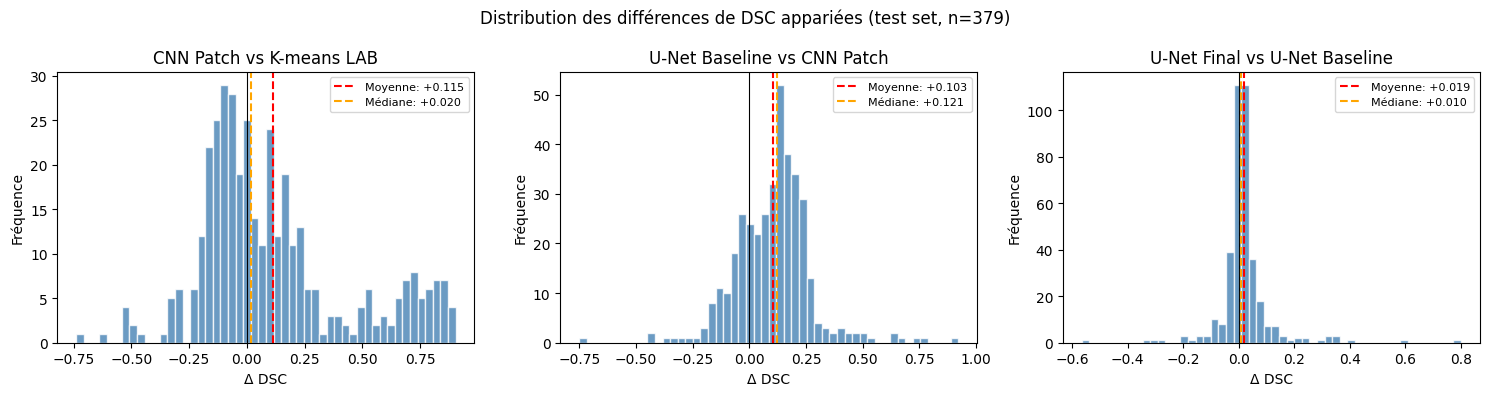

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

pairs = [
    (dsc_km,  dsc_cnn,  'K-means LAB', 'CNN Patch'),
    (dsc_cnn, dsc_base, 'CNN Patch',   'U-Net Baseline'),
    (dsc_base, dsc_fin, 'U-Net Baseline', 'U-Net Final'),
]

for ax, (a, b, na, nb) in zip(axes, pairs):
    diff = b - a
    ax.hist(diff, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(0, color='black', linestyle='-', linewidth=0.8)
    ax.axvline(diff.mean(), color='red', linestyle='--', linewidth=1.5, 
               label=f'Moyenne: {diff.mean():+.3f}')
    ax.axvline(np.median(diff), color='orange', linestyle='--', linewidth=1.5,
               label=f'Médiane: {np.median(diff):+.3f}')
    ax.set_xlabel('Δ DSC')
    ax.set_ylabel('Fréquence')
    ax.set_title(f'{nb} vs {na}')
    ax.legend(fontsize=8)

plt.suptitle('Distribution des différences de DSC appariées (test set, n=379)', fontsize=12)
plt.tight_layout()
plt.savefig('figures/fig_wilcoxon_distributions.pdf', bbox_inches='tight')
plt.show()

/tmp/ipykernel_999/3692110802.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True, showmeans=True,


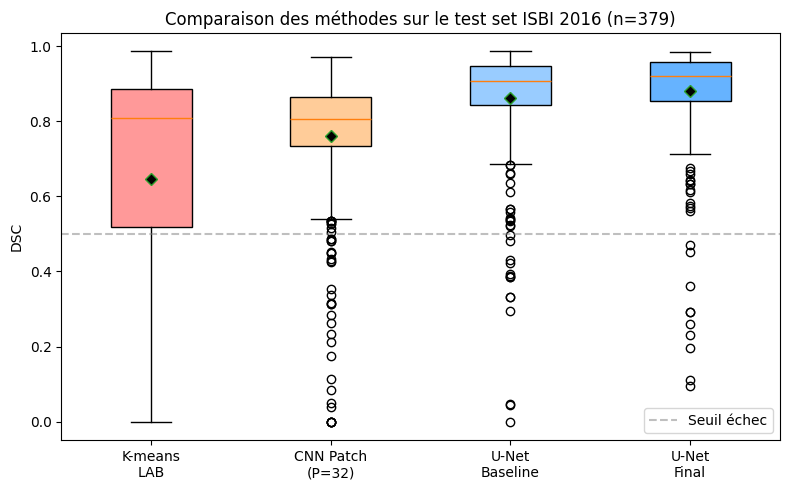

In [20]:
# Boxplot comparatif
fig, ax = plt.subplots(figsize=(8, 5))

data = [dsc_km, dsc_cnn, dsc_base, dsc_fin]
labels = ['K-means\nLAB', 'CNN Patch\n(P=32)', 'U-Net\nBaseline', 'U-Net\nFinal']

bp = ax.boxplot(data, labels=labels, patch_artist=True, showmeans=True,
                meanprops=dict(marker='D', markerfacecolor='black', markersize=6))

colors = ['#ff9999', '#ffcc99', '#99ccff', '#66b3ff']
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c)

ax.set_ylabel('DSC')
ax.set_title('Comparaison des méthodes sur le test set ISBI 2016 (n=379)')
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Seuil échec')
ax.legend()
plt.tight_layout()
plt.savefig('figures/fig_wilcoxon_boxplot.pdf', bbox_inches='tight')
plt.show()

## 7. Sauvegarde des résultats

In [21]:
# Sauvegarder les DSC per-image pour reproductibilité
output = {
    'test_set_size': 379,
    'per_image': df[['image', 'kmeans_lab', 'cnn_patch', 'unet_baseline', 'unet_final']].to_dict('records'),
    'wilcoxon_tests': tests,
    'summary': {
        method: {
            'mean': round(float(df[method].mean()), 4),
            'std': round(float(df[method].std()), 4),
            'median': round(float(df[method].median()), 4),
        }
        for method in ['kmeans_lab', 'cnn_patch', 'unet_baseline', 'unet_final']
    }
}

with open('results_wilcoxon_tests.json', 'w') as f:
    json.dump(output, f, indent=2)

print("Résultats sauvegardés dans results_wilcoxon_tests.json")
print("Figures sauvegardées dans figures/fig_wilcoxon_*.pdf")

Résultats sauvegardés dans results_wilcoxon_tests.json
Figures sauvegardées dans figures/fig_wilcoxon_*.pdf


In [22]:
# Tableau récapitulatif pour le mémoire
print("\n" + "="*80)
print("TABLEAU POUR LE MÉMOIRE")
print("="*80)
print("\nComparaisons appariées (Wilcoxon signed-rank test, n=379):")
print()
for t in tests:
    print(f"  {t['Comparaison']:35s}  Δ={t['Δ DSC moyen']:+.4f}   p={t['p-value']}   {t['Significatif']}")
    print(f"{'':35s}  (B > A: {t['n_sup']},  A > B: {t['n_inf']},  égaux: {t['n_egal']})")
    print()


TABLEAU POUR LE MÉMOIRE

Comparaisons appariées (Wilcoxon signed-rank test, n=379):

  CNN Patch vs K-means LAB             Δ=+0.1148   p=3.00e-06   *** (p < 0.001)
                                     (B > A: 203,  A > B: 172,  égaux: 4)

  U-Net Baseline vs CNN Patch          Δ=+0.1029   p=9.42e-30   *** (p < 0.001)
                                     (B > A: 287,  A > B: 91,  égaux: 1)

  U-Net Final vs U-Net Baseline        Δ=+0.0185   p=4.23e-09   *** (p < 0.001)
                                     (B > A: 249,  A > B: 130,  égaux: 0)

  U-Net Final vs K-means LAB           Δ=+0.2362   p=2.81e-47   *** (p < 0.001)
                                     (B > A: 333,  A > B: 46,  égaux: 0)

